In [1]:
# End-to-End Exploratory Data Analysis (EDA) 
# Assignment – Real World Business Scenario 
# . 
# Dataset 
# Kaggle Dataset: Superstore Sales Dataset 
# Link: https://www.kaggle.com/datasets/vivek468/superstore-dataset-final 
# Business Scenario 
# You are working as a Data Analyst for a retail company that sells products across multiple regions. 
# The management team wants to understand sales performance, customer purchasing patterns, and 
# profitability trends. Your task is to perform a complete Exploratory Data Analysis to generate 
# actionable insights that can help the company improve sales and operational strategy. 


# Stage 1 – Project Setup (Industry SOP) 
# 1 Create a new GitHub repository named: retail-sales-eda 
# 2 Clone the repository to your local machine. 
# 3 Create the following folder structure: 
# 4 retail-sales-eda/ 
# |
#  data/ 
#  notebooks/ 
#  images/ 
#  src/ 
#  README.md

In [2]:
# Stage 2 – Data Loading and Inspection 


# importing pandas as pd
import pandas as pd


# Load the dataset using pandas. 
df = pd.read_csv('../data/Sample.csv', encoding='unicode_escape')

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [3]:


# Print the first 10 rows of the dataset to get an initial understanding of the data structure and contents.
print(df.head(10))

# Print the last 10 rows of the dataset to get an initial understanding of the data structure and contents.
# print(df.tail(2))

   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
5       6  CA-2014-115812    6/9/2014   6/14/2014  Standard Class    BH-11710   
6       7  CA-2014-115812    6/9/2014   6/14/2014  Standard Class    BH-11710   
7       8  CA-2014-115812    6/9/2014   6/14/2014  Standard Class    BH-11710   
8       9  CA-2014-115812    6/9/2014   6/14/2014  Standard Class    BH-11710   
9      10  CA-2014-115812    6/9/2014   6/14/2014  Standard Class    BH-11710   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United 

In [4]:
# 3 Check dataset shape (rows and columns).
print(df.shape)

# 4 Identify column data types. 
print(df.dtypes)

(9994, 21)
Row ID             int64
Order ID          object
Order Date        object
Ship Date         object
Ship Mode         object
Customer ID       object
Customer Name     object
Segment           object
Country           object
City              object
State             object
Postal Code        int64
Region            object
Product ID        object
Category          object
Sub-Category      object
Product Name      object
Sales            float64
Quantity           int64
Discount         float64
Profit           float64
dtype: object


In [5]:
# 5 Check for missing values. 
print(df.isnull().sum())

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64


In [6]:
# Stage 3 – Data Cleaning 

# 1 Handle missing values appropriately.
# For simplicity, we will drop rows with missing values. In a real-world scenario, you might want to consider imputation or other strategies.
df_cleaned = df.dropna()


# 2 Check for duplicate records. 
duplicates = df_cleaned.duplicated()
print(f"Number of duplicate records: {duplicates.sum()}")

# If duplicates exist, you can choose to drop them.
df_cleaned = df_cleaned.drop_duplicates()

# 3 Correct inconsistent data types. 
# For example, if 'Order Date' is not in datetime format, we can convert it.
df_cleaned['Order Date'] = pd.to_datetime(df_cleaned['Order Date'], errors='coerce')

print(df_cleaned.dtypes)

Number of duplicate records: 0
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date                object
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [7]:
# 4 Verify categorical variables. 
# For example, check unique values in the 'Category' column.
print(df_cleaned['Category'].unique())

['Furniture' 'Office Supplies' 'Technology']


In [10]:
# Stage 4 – Exploratory Data Analysis

# 1 Identify top performing product categories. 
top_categories = df_cleaned.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(top_categories)

# 2 Analyze sales distribution across regions. 
sales_by_region = df_cleaned.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(sales_by_region)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64
Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64


In [13]:
# 3 Determine which customer segments generate the most revenue. 

revenue_by_segment = df_cleaned.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
print(revenue_by_segment)



# 4 Analyze monthly or yearly sales trends. 

df_cleaned['Year'] = df_cleaned['Order Date'].dt.year
df_cleaned['Month'] = df_cleaned['Order Date'].dt.month
sales_by_year = df_cleaned.groupby('Year')['Sales'].sum()
sales_by_month = df_cleaned.groupby('Month')['Sales'].sum()
print(sales_by_year)
print(sales_by_month)

Segment
Consumer       1.161401e+06
Corporate      7.061464e+05
Home Office    4.296531e+05
Name: Sales, dtype: float64
Year
2014    484247.4981
2015    470532.5090
2016    609205.5980
2017    733215.2552
Name: Sales, dtype: float64
Month
1      94924.8356
2      59751.2514
3     205005.4888
4     137762.1286
5     155028.8117
6     152718.6793
7     147238.0970
8     159044.0630
9     307649.9457
10    200322.9847
11    352461.0710
12    325293.5035
Name: Sales, dtype: float64


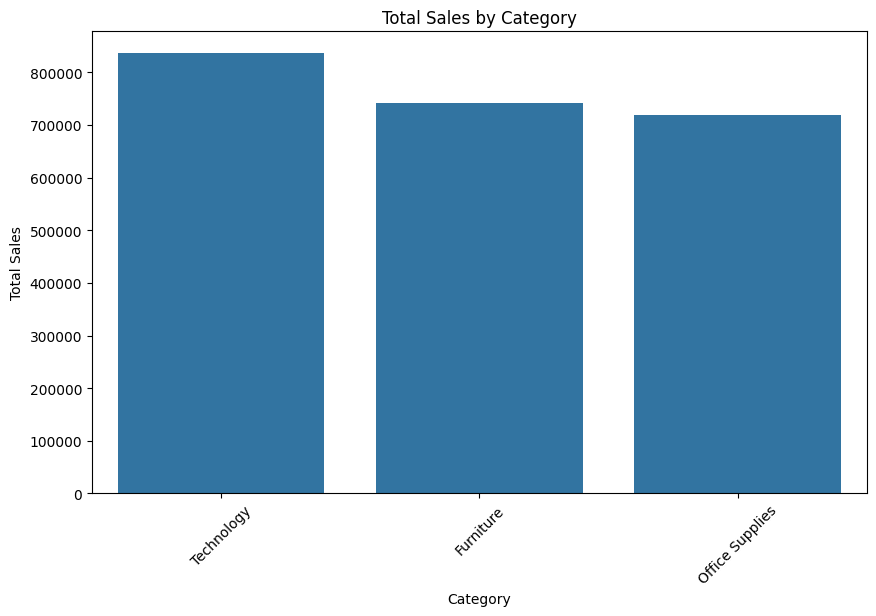

In [17]:
# Stage 5 – Visualization 

# 1)  Create bar charts for category sales with seaborn. 
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.barplot(x=top_categories.index, y=top_categories.values)
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.show()



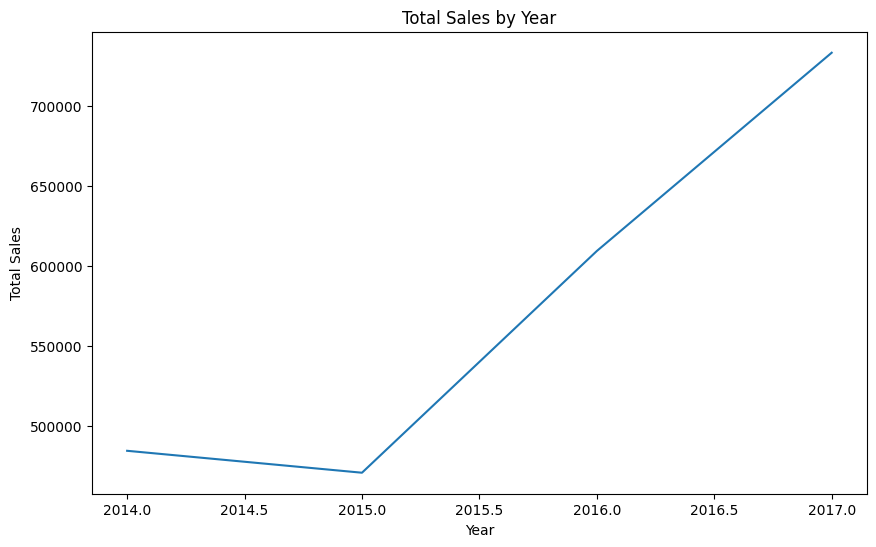

In [19]:
# 2 Create line charts for sales trends. 

plt.figure(figsize=(10, 6))
sns.lineplot(x=sales_by_year.index, y=sales_by_year.values)
plt.title('Total Sales by Year')
plt.xlabel('Year')
plt.ylabel('Total Sales')
plt.show()

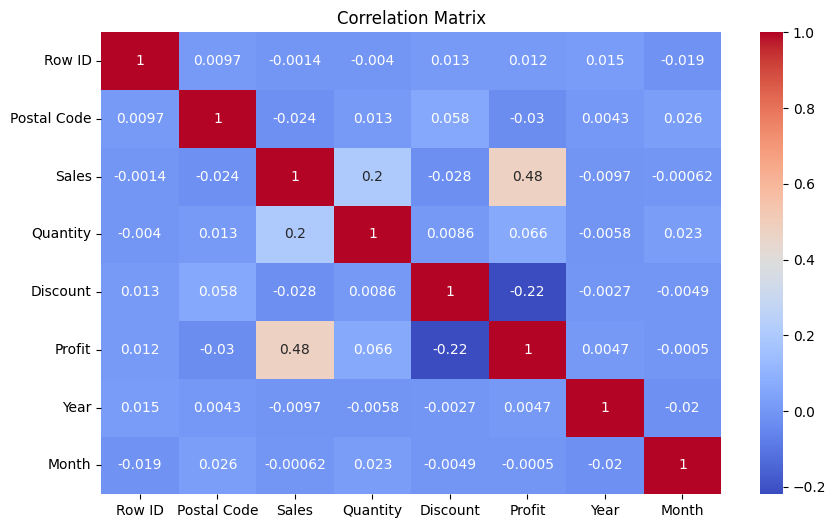

In [21]:
# 3 Create heatmaps for correlation analysis. 

numeric_df = df_cleaned.select_dtypes(include='number')
correlation_matrix = numeric_df.corr()
plt.figure(figsize=(10, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix')
plt.show()

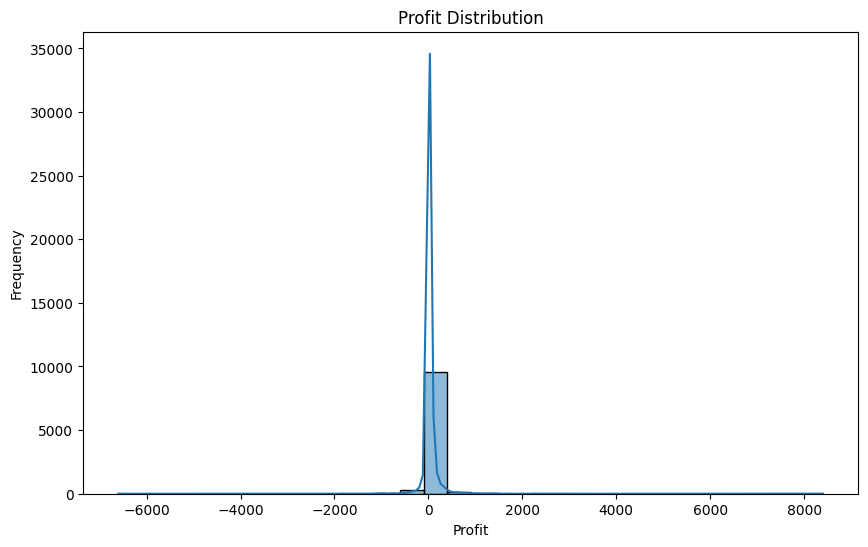

In [22]:
# 4 Visualize profit distribution. 
plt.figure(figsize=(10, 6))
sns.histplot(df_cleaned['Profit'], bins=30, kde=True)
plt.title('Profit Distribution')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

In [24]:
# Stage 6 – Insight Generation 

# 1 Identify most profitable products. 
profit_by_product = df_cleaned.groupby('Product Name')['Profit'].sum().sort_values(ascending=False)
print(profit_by_product.head(10))


Product Name
Canon imageCLASS 2200 Advanced Copier                                          25199.9280
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind     7753.0390
Hewlett Packard LaserJet 3310 Copier                                            6983.8836
Canon PC1060 Personal Laser Copier                                              4570.9347
HP Designjet T520 Inkjet Large Format Printer - 24" Color                       4094.9766
Ativa V4110MDD Micro-Cut Shredder                                               3772.9461
3D Systems Cube Printer, 2nd Generation, Magenta                                3717.9714
Plantronics Savi W720 Multi-Device Wireless Headset System                      3696.2820
Ibico EPK-21 Electric Binding System                                            3345.2823
Zebra ZM400 Thermal Label Printer                                               3343.5360
Name: Profit, dtype: float64


In [26]:
# 2 Identify least profitable regions. 

profit_by_region = df_cleaned.groupby('Region')['Profit'].sum().sort_values()
print(profit_by_region)

Region
Central     39706.3625
South       46749.4303
East        91522.7800
West       108418.4489
Name: Profit, dtype: float64


In [ ]:
# 3 Recommend strategies for improving sales. 
